# Exploratory Data Analysis (EDA)

This notebook explores the **price dynamics of agricultural commodities** across different varieties, markets, and seasons.  
The goal is to uncover **patterns, correlations, and factors** influencing price movements, providing a foundation for modeling and interpretation.

## Data Loading and Setup

In this step, we import the required libraries for data analysis and visualization.  
We configure pandas to display all rows and columns for easier inspection.  

Finally, we load the cleaned **commodity price dataset** using our custom `load_data` utility function and generate a descriptive summary to understand the structure of the data.

In [1]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway   # ANOVA test
from statsmodels.stats.multitest import multipletests  # multiple testing correction

# Custom utility function to load the dataset
from utils.load_data import load_data

# Configure pandas display options to show all rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load the dataset and inspect basic descriptive statistics
df = load_data('data/commodity_prices.csv')
df.describe(include='all')

,Product_Type,Commodity,Variety_Type,Arrival_Date,Market,Is_VFPCK,Season,Year,Modal_Price,log_Modal_Price,Max_Price,Min_Price
count,166028,166028,166028,166028,166028,166028,166028,166028.000000,166028.000000,166028.000000,166028.000000,166028.000000
unique,116,55,105,NaN,27,2,4,NaN,NaN,NaN,NaN,NaN
top,Ashgourd|Ashgourd|FAQ,Banana,Banana|Palayamthodan,NaN,Perumbavoor,False,Southwest Monsoon,NaN,NaN,NaN,NaN,NaN
freq,5166,17035,5954,NaN,22123,141329,51555,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2024-08-09 13:25:38.892235008,NaN,NaN,NaN,2024.121353,5247.525315,8.350014,5892.604639,4707.825763
min,NaN,NaN,NaN,2023-06-01 00:00:00,NaN,NaN,NaN,2023.000000,300.000000,5.707110,0.000000,0.000000
25%,NaN,NaN,NaN,2024-02-05 00:00:00,NaN,NaN,NaN,2024.000000,3000.000000,8.006701,3500.000000,2500.000000
50%,NaN,NaN,NaN,2024-08-20 00:00:00,NaN,NaN,NaN,2024.000000,4200.000000,8.343078,5000.000000,3800.000000
75%,NaN,NaN,NaN,2025-02-23 00:00:00,NaN,NaN,NaN,2025.000000,5700.000000,8.648397,6400.000000,5000.000000
max,NaN,NaN,NaN,2025-08-18 00:00:00,NaN,NaN,NaN,2025.000000,90000.000000,11.407576,110000.000000,75000.000000


## ANOVA Test: Seasonal Price Variation

Here, we test whether commodity prices show **significant variation across different seasons** for each product type.  

Steps performed:
1. Group the dataset by `Product_Type`.
2. Within each product type, further split data into seasonal groups.
3. Filter out groups with zero variance (to avoid errors in ANOVA).
4. Apply **one-way ANOVA (f_oneway)** when there are at least two valid seasonal groups.
5. Store the results (F-statistic and p-value) for each product type.
6. Convert results into a DataFrame, sort by p-value, and display the top 10 most significant results.

In [2]:
# Dictionary to store ANOVA results
anova_results = {}

# Perform ANOVA test for each product type
for product_type, group in df.groupby('Product_Type'):
    # Create seasonal groups of prices
    seasonal_groups = [seasonal_group['Modal_Price'].values 
                       for name, seasonal_group in group.groupby('Season')]
    
    # Filter out groups with zero variance (std = 0)
    seasonal_groups = [arr for arr in seasonal_groups if arr.std() > 0]
    
    # Run ANOVA only if there are at least 2 valid groups
    if len(seasonal_groups) >= 2:
        stat, pval = f_oneway(*seasonal_groups)
        anova_results[product_type] = {'F-statistic': stat, 'p-value': pval}
    else: 
        continue

# Convert results into a DataFrame for easier filtering/sorting
anova_df = pd.DataFrame(anova_results).T.reset_index().rename(columns={'index': 'Product_Type'})

# Sort by p-value (ascending → most significant effects first)
anova_df = anova_df.sort_values(by='p-value', ascending=True).reset_index(drop=True)

# Show the top 10 product types with strongest seasonal effects
anova_df.head(10)

,Product_Type,F-statistic,p-value
0,Drumstick|Drumstick|FAQ,740.078779,0.000000e+00
1,Ashgourd|Ashgourd|FAQ,672.884547,0.000000e+00
2,Onion|Big|FAQ,561.238630,5.204789e-291
3,Green Chilli|Green Chilly|FAQ,520.872348,4.627220e-278
4,Mango (Raw-Ripe)|Mango - Raw-Ripe|FAQ,502.608828,1.451589e-257
5,Banana|Palayamthodan|Large,388.413965,7.489628e-217
6,Bitter gourd|Bitter Gourd|FAQ,363.326266,5.799831e-209
7,Banana|Nendra Bale|Large,323.671476,5.213477e-192
8,Tomato|Tomato|FAQ,292.476120,1.393565e-162
9,Carrot|Carrot|FAQ,184.842655,4.596799e-111


### Interpretation of ANOVA Results

The ANOVA test confirms that **most commodities (>90%) exhibit significant seasonal price variation**.  
This means seasonality is a strong driver of price changes in the dataset.

**High seasonal impact (large F-statistics, very low p-values):**
- Banana (Nendra Bale, Palayamthodan)
- Ashgourd
- Drumstick
- Onion (Big)
- Bitter Gourd
- Ginger (Green)

**Low or no seasonal effect:**
- Amaranthus
- Cowpea (Bean Barbati)
- Papaya (Raw)
- Onion (1st Sort Non-FAQ)

**Borderline cases:**
- French Beans
- Watermelon
- Amaranthus (Other)

These results align with expectations: **perishable crops and those with short harvest cycles** show the strongest seasonal swings, while hardier or less perishable commodities exhibit weaker seasonal patterns.

### Linking ANOVA Results with VFPCK Presence

Next, we examine whether the **VFPCK markets (Vegetable and Fruit Promotion Council of Kerala)** influence the seasonal price variations observed.

Steps performed:
1. For each product type:
   - Create a Boolean flag (`Has_VFPCK`) indicating whether the commodity appears in any VFPCK market.
   - Calculate the fraction of records from VFPCK markets (`Pct_VFPCK`).
2. Merge these statistics into the ANOVA results table.
3. Filter to include only commodities with VFPCK presence.
4. Sort commodities by the percentage of VFPCK coverage for easier interpretation.
5. Display the top 10 commodities with the highest VFPCK representation.

In [3]:
# Boolean flag: whether a product type appears at least once in VFPCK
vfpck_flag = (
    df.groupby('Product_Type')['Is_VFPCK']
      .any()
      .reset_index()
      .rename(columns={'Is_VFPCK': 'Has_VFPCK'})
)

# Fraction of records that come from VFPCK markets (per product type)
vfpck_stats = (
    df.groupby('Product_Type')['Is_VFPCK']
      .mean()
      .reset_index()
      .rename(columns={'Is_VFPCK': 'Pct_VFPCK'})
)

# Merge ANOVA results with VFPCK statistics
vfpck_df = anova_df.merge(vfpck_stats, on='Product_Type', how='left')
vfpck_df = vfpck_df.merge(vfpck_flag, on='Product_Type', how='left')

# Keep only commodities with VFPCK presence
vfpck_df = vfpck_df[vfpck_df['Has_VFPCK'] == True]

# Sort by percentage of VFPCK coverage (descending)
vfpck_df = vfpck_df.sort_values('Pct_VFPCK', ascending=False).reset_index(drop=True)

# Display top 10 commodities most represented in VFPCK markets
vfpck_df.head(10)

,Product_Type,F-statistic,p-value,Pct_VFPCK,Has_VFPCK
0,Banana|Nendra Bale|Medium,0.000003,9.986209e-01,1.000000,True
1,Papaya|Other|Large,209.734322,8.316692e-95,1.000000,True
2,Banana|Robusta|Medium,12.401075,1.544887e-05,1.000000,True
3,Pineapple|Other|Small,29.093374,2.073386e-17,1.000000,True
4,Banana|Robusta|Large,46.612930,3.607105e-29,1.000000,True
5,Banana|Nendra Bale|Large,323.671476,5.213477e-192,0.865049,True
6,Banana|Palayamthodan|Large,388.413965,7.489628e-217,0.815317,True
7,Banana|Poovan|Large,141.712494,2.568108e-85,0.813877,True
8,Papaya|Papaya|Large,23.459957,2.037139e-14,0.784496,True
9,Pineapple|Other|Large,74.815843,9.775584e-46,0.671924,True


### Interpretation of VFPCK Analysis

VFPCK’s presence has increased market access for farmers, with many commodities showing high percentages of records from VFPCK markets.  

However, our analysis indicates that **seasonal price swings remain significant** even for products with strong VFPCK representation (e.g., Bananas, Papaya, Pineapple). This suggests that while VFPCK ensures market inclusion, it does not fully buffer farmers from seasonal volatility.

Key insight:
- **Perishability** plays a critical role. Highly perishable crops cannot be stored across seasons, limiting VFPCK’s ability to stabilize prices through direct market access alone.
- **Policy implication:** Rather than focusing solely on market access, complementary measures such as:
  - Value addition (processing into shelf-stable products),
  - Short-term cold chain investments,
  - Market diversification, and
  - Forward contracting,  
  would be more effective in protecting farmer incomes from seasonal fluctuations.

---

### Banana | Nendra Bale | Large

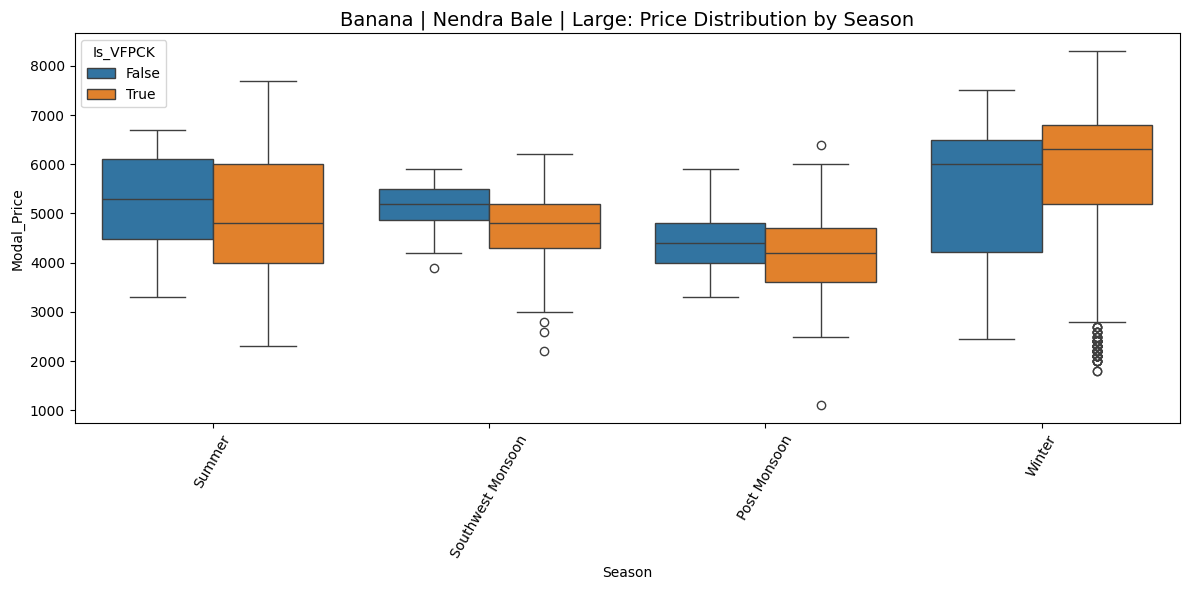

In [4]:
# Plot seasonal price distribution for Banana (Nendra Bale, Large)
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df[df['Product_Type'] == 'Banana|Nendra Bale|Large'], 
    x='Season', 
    y='Modal_Price', 
    hue='Is_VFPCK',
    ax=ax
)

# Set title and formatting
ax.set_title('Banana | Nendra Bale | Large: Price Distribution by Season', fontsize=14)
plt.xticks(rotation=60)
plt.tight_layout()

# Save figure to figures folder (already exists)
fig.savefig("figures/banana_nendra_bale_large_seasonal.png", dpi=300)

# Display plot
plt.show()

---

### Pineapple | Other | Small

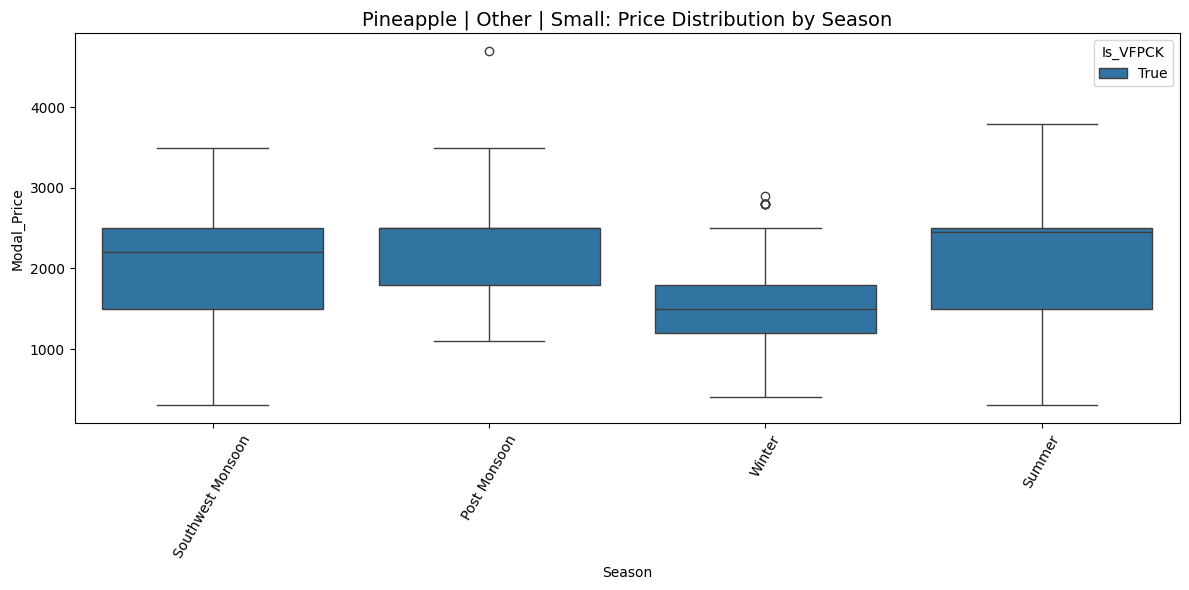

In [5]:
# Plot seasonal price distribution for Pineapple (Other, Small)
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df[df['Product_Type'] == 'Pineapple|Other|Small'], 
    x='Season', 
    y='Modal_Price', 
    hue='Is_VFPCK',
    ax=ax
)

# Title and formatting
ax.set_title('Pineapple | Other | Small: Price Distribution by Season', fontsize=14)
plt.xticks(rotation=60)
plt.tight_layout()

# Save figure to figures folder
fig.savefig("figures/pineapple_other_small_seasonal.png", dpi=300)

# Display plot
plt.show()

### Interpretation of Case Study Plots

The boxplots reinforce the ANOVA findings:

- **Banana | Nendra Bale | Large**  
  Despite VFPCK coverage, seasonal swings are very visible.  
  Prices drop sharply during the **Post Monsoon** and rise again in **Winter**, with wide variability.  
  VFPCK markets do not appear to buffer this volatility — distributions for VFPCK and non-VFPCK largely overlap.

- **Pineapple | Other | Small**  
  This commodity shows **less dramatic seasonal shifts** compared to Banana.  
  However, variation across seasons is still evident, with lower median prices in **Winter**.  
  Since Pineapple is strongly represented in VFPCK markets, this confirms that **perishability, not just market channel**, drives seasonal price fluctuations.

**Link back to ANOVA results:**  
- Commodities with the largest ANOVA F-statistics (e.g., Banana) show exactly the strong seasonal patterns visible in their boxplots.  
- Crops with lower F-statistics (e.g., Pineapple) exhibit milder seasonal differences, but variation is still non-trivial.  
Together, these plots validate the statistical test outcomes and highlight where VFPCK influence is limited by biological and storage constraints.

##  ANOVA Test: Yearly Price Variation

To investigate whether commodity prices vary significantly across years (after accounting for season and market), we conducted a one-way ANOVA for each **Product × Market × Season** combination.

- Only groups with at least 2 years of data were considered.
- Years with a single observation or constant variance were excluded to avoid invalid tests.
- We applied the **Benjamini–Hochberg (FDR) correction** to adjust for multiple comparisons.

In [6]:
results = []
for (prod, market, season), group in df.groupby(['Product_Type', 'Market', 'Season']):
    if group['Year'].nunique() > 1:  # need at least 2 years
        samples = [grp['Modal_Price'].values for _, grp in group.groupby('Year')]
        
        # keep only groups with n>=2 and non-constant variance
        valid_samples = [s for s in samples if len(s) > 1 and s.std() > 0]
        
        if len(valid_samples) >= 2:
            stat, p = f_oneway(*valid_samples)
            results.append({
                'Product': prod,
                'Market': market,
                'Season': season,
                'F_stat': stat,
                'p_value': p
            })

results_df = pd.DataFrame(results)
results_df['reject'], results_df['p_adj'], _, _ = multipletests(
    results_df['p_value'], method='fdr_bh'
)

results_df['reject'].value_counts(normalize=True)


reject
True     0.799317
False    0.200683
Name: proportion, dtype: float64

### Findings

- **~80% of Product × Market × Season groups** show statistically significant year-to-year price variation.
- This suggests that **annual shocks** — such as weather changes, pest outbreaks, policy interventions, or broader market conditions — play a major role in shaping prices.
- The remaining ~20% of groups show stability across years, meaning that for those commodities, **seasonality and market structure** dominate over annual effects.
- In summary, while seasonality strongly influences prices (Section 2), the data shows that **yearly factors amplify volatility for most commodities**.

---

### Banana - Green|Banana - Green|FAQ

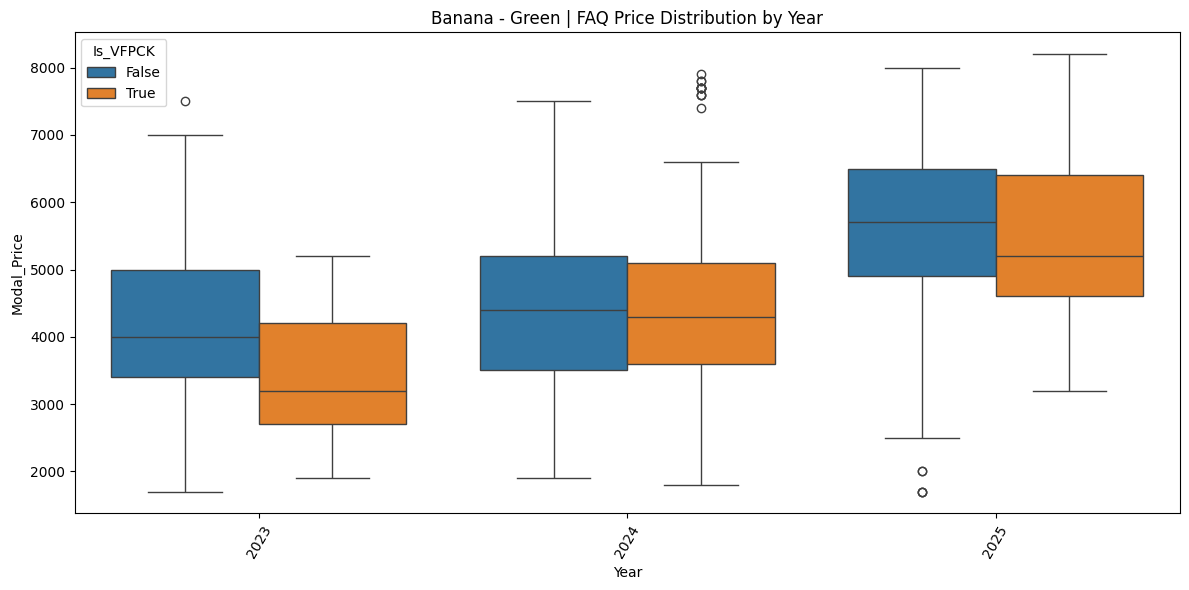

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot: Yearly price variation for Banana - Green | FAQ
sns.boxplot(
    data=df[df['Product_Type'] == 'Banana - Green|Banana - Green|FAQ'],
    x='Year',
    y='Modal_Price',
    hue='Is_VFPCK',
    ax=ax
)

# Add title and adjust x-axis
ax.set_title("Banana - Green | FAQ Price Distribution by Year")
plt.xticks(rotation=60)

# Adjust layout to avoid cut-off labels
plt.tight_layout()

# Save the figure
fig.savefig("figures/banana_green_faq_yearly.png", dpi=300)

# Show the figure
plt.show()

---

### Ginger(Green)|Green Ginger|FAQ

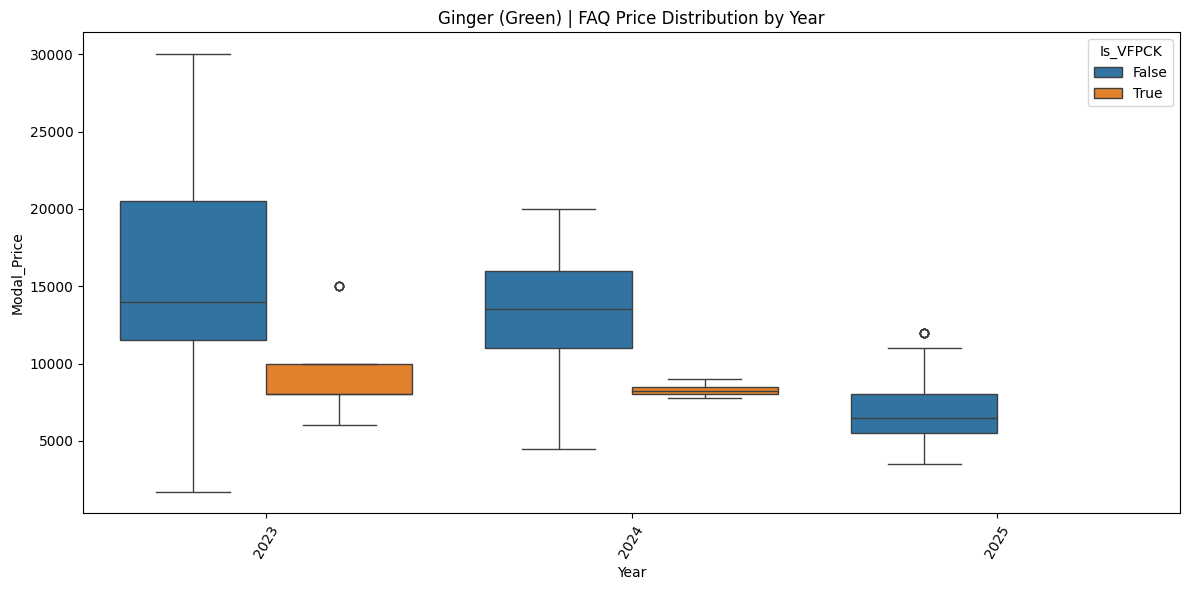

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot: Yearly price variation for Green Ginger | FAQ
sns.boxplot(
    data=df[df['Product_Type'] == 'Ginger(Green)|Green Ginger|FAQ'],
    x='Year',
    y='Modal_Price',
    hue='Is_VFPCK',
    ax=ax
)

# Add title and adjust x-axis
ax.set_title("Ginger (Green) | FAQ Price Distribution by Year")
plt.xticks(rotation=60)

# Adjust layout
plt.tight_layout()

# Save the figure
fig.savefig("figures/ginger_green_faq_yearly.png", dpi=300)

# Show the figure
plt.show()

### Example Visuals of Yearly Effects  

- **Banana - Green | FAQ**: Prices show a steady upward shift from 2023 → 2025 across both VFPCK and non-VFPCK markets, reinforcing the ANOVA result that yearly shocks (inflation, climate, costs) systematically raise prices.  

- **Ginger (Green) | FAQ**: Prices are extremely volatile in 2023, then stabilize at lower levels in 2024–2025. This reflects sharp year-specific shocks, likely supply-driven, that contribute to strong yearly effects.  

## Market Effects on Price Variation  

Next, we test whether **market location itself** drives systematic price variation, independent of year and season.  
We perform **ANOVA across markets** for each product–season–year combination, then apply **multiple testing correction** to ensure robustness.  

In [9]:
market_results = []

# Group data by Product, Season, and Year to ensure fair comparisons
for (prod, season, year), group in df.groupby(['Product_Type', 'Season', 'Year']):
    if group['Market'].nunique() > 1:  # Only consider cases with ≥2 markets
        # Collect prices per market
        samples = [grp['Modal_Price'].values for _, grp in group.groupby('Market')]
        
        # Keep only valid samples (≥2 observations and non-zero variance)
        valid_samples = [s for s in samples if len(s) > 1 and s.std() > 0]
        
        # Run ANOVA only if ≥2 valid markets remain
        if len(valid_samples) >= 2:
            stat, p = f_oneway(*valid_samples)
            market_results.append({
                'Product': prod,
                'Season': season,
                'Year': year,
                'F_stat': stat,
                'p_value': p
            })

# Collect results into a DataFrame
market_df = pd.DataFrame(market_results)

market_df['reject'], market_df['p_adj'], _, _ = multipletests(
    market_df['p_value'], method='fdr_bh'
)

# Summary: proportion of product-season-year cases with significant market effect
market_df['reject'].value_counts(normalize=True)

reject
True     0.934524
False    0.065476
Name: proportion, dtype: float64

### Findings:
The results show that **market location has a strong effect** on price formation:  
- In **~93% of cases**, market differences are statistically significant even after correction.  
- This confirms that **where a commodity is sold** consistently matters for its price, beyond seasonal and yearly effects.  

Together, seasonality, yearly shocks, and market structure explain much of the price variability observed in Ernakulam.  

---

### Banana|Poovan|Large

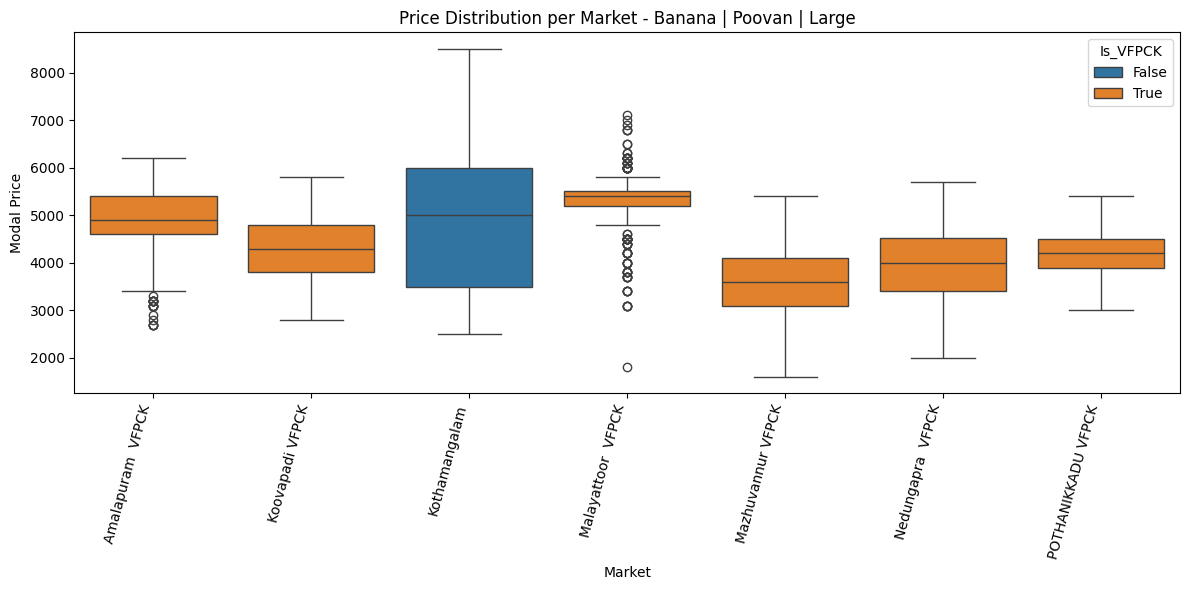

In [10]:
plt.figure(figsize=(12,6))

# Boxplot of prices across markets, split by VFPCK vs Non-VFPCK
sns.boxplot(
    data=df[df['Product_Type'] == 'Banana|Poovan|Large'],
    x='Market',
    y='Modal_Price',
    hue='Is_VFPCK'
)

# Rotate x-axis labels for readability
plt.xticks(rotation=75, ha='right')

# Add titles and axis labels
plt.title("Price Distribution per Market - Banana | Poovan | Large")
plt.ylabel("Modal Price")
plt.xlabel("Market")

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save figure in the 'figures' folder
plt.savefig("figures/banana_poovan_large_market.png", dpi=300)

# Display plot
plt.show()

---

### Tapioca|Tapioca|FAQ

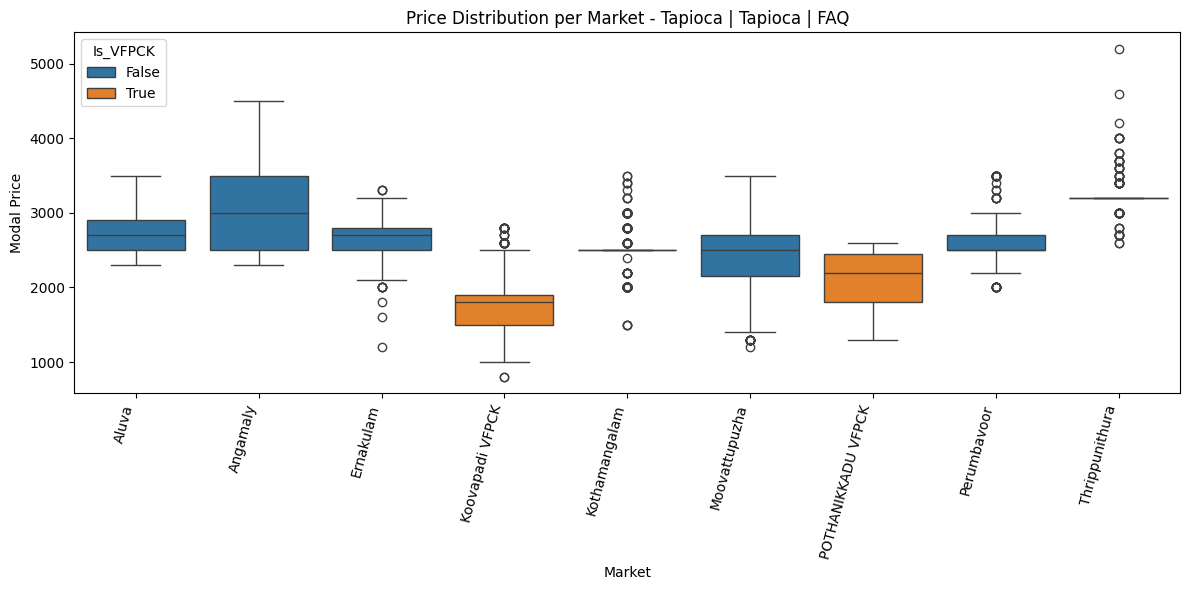

In [11]:
plt.figure(figsize=(12,6))

# Boxplot of prices across markets, split by VFPCK vs Non-VFPCK
sns.boxplot(
    data=df[df['Product_Type'] == 'Tapioca|Tapioca|FAQ'],
    x='Market',
    y='Modal_Price',
    hue='Is_VFPCK'
)

# Rotate x-axis labels for readability
plt.xticks(rotation=75, ha='right')

# Add titles and axis labels
plt.title("Price Distribution per Market - Tapioca | Tapioca | FAQ")
plt.ylabel("Modal Price")
plt.xlabel("Market")

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save figure in the 'figures' folder
plt.savefig("figures/tapioca_faq_market.png", dpi=300)

# Display plot
plt.show()

#### Supporting Visualizations  

- **Banana | Poovan | Large**  
  The plot shows that **prices vary widely across markets**, with Malayattoor VFPCK consistently achieving higher prices compared to Kothamangalam and Mazhuvannur VFPCK. The variation is not only in the median price but also in the spread, reflecting higher uncertainty and volatility in some markets. This aligns with the ANOVA results confirming market-level price effects.  

- **Tapioca | Tapioca | FAQ**  
  Here, price differences across markets are even more striking. For instance, **Koovapadi VFPCK records significantly lower prices** compared to Ernakulam and Perumbavoor, which maintain relatively stable and higher ranges. The separation between VFPCK and non-VFPCK markets is also visible in this case, showing structural pricing differences.  


## Commodity Effect on Price  

In addition to seasonality, yearly, and market factors, we test whether the **type of commodity itself** explains variation in modal prices. Some commodities (e.g., Banana, Ginger, Tapioca) may have inherently different pricing structures due to production costs, demand, perishability, or export potential.  

To evaluate this, we conduct a **one-way ANOVA across all commodities**, treating each commodity as a group. If the test shows significant differences, it means that modal price levels vary systematically between commodities.

In [12]:
# Group all prices by commodity (ignores variety/grade for now)
commodity_groups = [grp['Modal_Price'].values for _, grp in df.groupby('Commodity')]

# Keep only groups with enough observations and non-zero variance
valid_groups = [g for g in commodity_groups if len(g) > 1 and g.std() > 0]

# Run one-way ANOVA across commodities if valid groups exist
if len(valid_groups) >= 2:
    stat, pval = f_oneway(*valid_groups)
    print("Commodity-level ANOVA: F =", stat, "p =", pval)
else:
    print("Not enough valid commodity groups for ANOVA")

Commodity-level ANOVA: F = 20908.489023962087 p = 0.0


#### Findings  

The ANOVA results show:  

- **F-statistic = 20,908.49**,  
- **p-value ≈ 0.0** (highly significant).  

This confirms that **commodity choice itself is a dominant driver of price differences**.  
For example, high-value crops like **Ginger** or **Banana (Nendra Bale)** are priced far above bulk staples like **Tapioca**.  

Thus, in addition to temporal and spatial effects, the **baseline price level strongly depends on the commodity**, underscoring the structural differences in Kerala’s agricultural markets.  

---

### Tomato

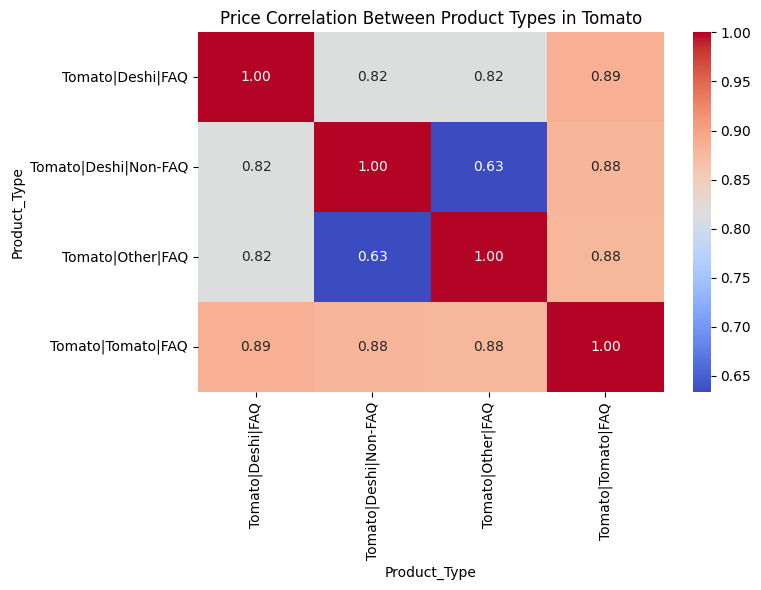

In [13]:
commodity = 'Tomato'
df_commodity = df[df['Commodity'] == commodity]

# --- Pivot table: dates as rows, product types as columns, prices as values ---
# This structure allows direct comparison of different product types over time
price_pivot = df_commodity.pivot_table(
    index='Arrival_Date',
    columns='Product_Type',
    values='Modal_Price'
)

# --- Correlation matrix between product types ---
# Captures how strongly prices move together across time
price_corr = price_pivot.corr()

# --- Heatmap for visual inspection of correlation ---
plt.figure(figsize=(8,6))
sns.heatmap(price_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Price Correlation Between Product Types in {commodity}')
plt.tight_layout()

# Save figure
plt.savefig("figures/tomato_product_correlation.png", dpi=300)
plt.show()

### Tomato – Product Type Correlation Heatmap  

The heatmap shows strong **positive correlations** between different product types of Tomato.  
- For example, *Tomato|Deshi|FAQ* and *Tomato|Tomato|FAQ* have a correlation of **0.89**, while *Tomato|Deshi|FAQ* and *Tomato|Deshi|Non-FAQ* correlate at **0.82**.  
- Even across categories like *Other* vs. *Deshi*, correlations remain high (0.81–0.88).  

**Interpretation:**  
Although prices vary by product type, they generally move in the **same direction**. This means product types under the same commodity are strongly linked in their price trends, reflecting shared supply-demand and seasonal factors.  

---

### Banana

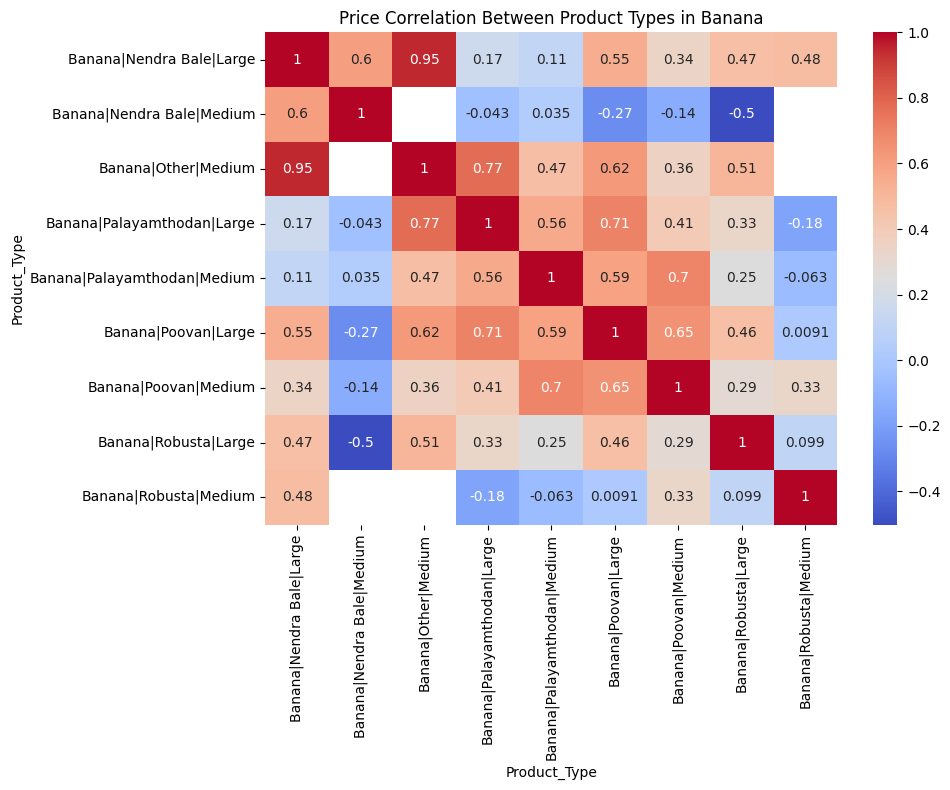

In [14]:
commodity = 'Banana'  # Select the commodity for analysis
df_commodity = df[df['Commodity'] == commodity]

# Pivot data: rows = dates, columns = product types, values = prices
price_pivot = df_commodity.pivot_table(
    index='Arrival_Date',
    columns='Product_Type',
    values='Modal_Price'
)

# Compute correlation matrix across product types
price_corr = price_pivot.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(price_corr, annot=True, cmap='coolwarm')
plt.title(f'Price Correlation Between Product Types in {commodity}')
plt.tight_layout()

# Save and show the heatmap
plt.savefig(f"figures/banana_price_correlation_heatmap.png", dpi=300)
plt.show()

### Banana – Product Type Correlation Heatmap  

The correlations between Banana product types are **more mixed** compared to Tomato.  
- Some pairs show strong positive correlations, such as *Nendra Bale (Large)* with *Other (Medium)* (**0.95**) and *Palayamthodan (Large)* with *Poovan (Large)* (**0.71**).  
- However, weaker or even negative correlations exist, e.g., *Nendra Bale (Medium)* vs. *Robusta (Large)* (**-0.50**) and *Nendra Bale (Medium)* vs. *Poovan (Large)* (**-0.27**).  

**Interpretation:**  
Unlike Tomato, Banana product types do not always move together. Certain varieties (like Nendra Bale and Other) are tightly linked, while others (like Robusta and Poovan) follow more independent pricing trends. This suggests that within Banana, **variety-specific dynamics**—such as demand patterns or supply cycles—play a stronger role.  

## Variety Type Effect on Price

To test whether **variety type within commodities** significantly influences modal prices,  
we run a one-way ANOVA across all `Variety_Type` groups. This checks if price differences between varieties  
(e.g., different types of bananas, tomatoes, or chilies) are statistically significant.

In [15]:
# Group all prices by variety type
variety_groups = [grp['Modal_Price'].values for _, grp in df.groupby('Variety_Type')]

# Keep only groups with enough data and variance
valid_groups = [g for g in variety_groups if len(g) > 1 and g.std() > 0]

# Run one-way ANOVA if we have at least 2 valid groups
if len(valid_groups) >= 2:
    stat, pval = f_oneway(*valid_groups)
    print("Variety-level ANOVA: F =", stat, "p =", pval)
else:
    print("Not enough valid variety groups for ANOVA")

Variety-level ANOVA: F = 11517.226750945483 p = 0.0


### Findings
The ANOVA test yields `F = 11517.23` with `p = 0.0`, indicating that **variety type strongly affects price**.  
This means that even within the same commodity, different varieties have systematically different price levels,  
likely reflecting quality, consumer preference, or supply-demand dynamics.

---
### Banana|Nendra Bale

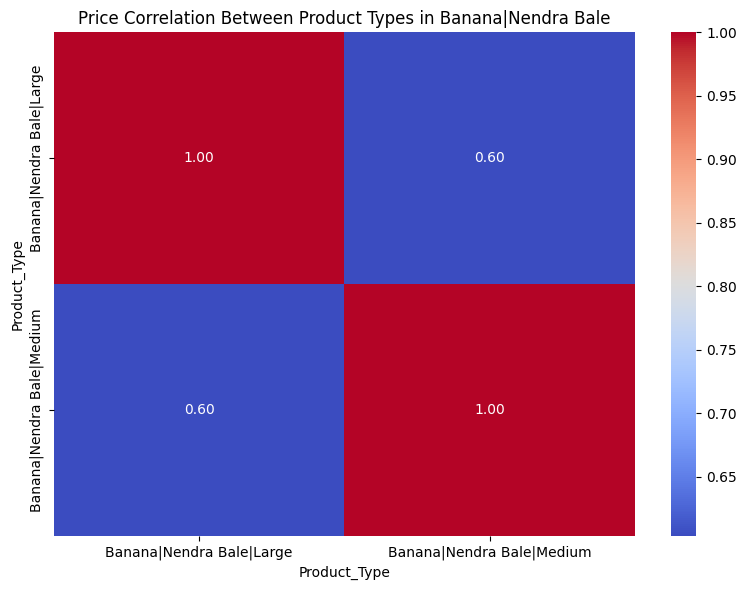

In [16]:
variety = 'Banana|Nendra Bale'  # Select the specific variety type
df_variety = df[df['Variety_Type'] == variety]  # Filter data for that variety

# Pivot table: rows = dates, columns = product types, values = modal prices
price_pivot = df_variety.pivot_table(
    index='Arrival_Date',
    columns='Product_Type',
    values='Modal_Price'
)

# Compute pairwise correlation across product types of this variety
price_corr = price_pivot.corr()

# Plot the heatmap to visualize correlation structure
plt.figure(figsize=(8, 6))
sns.heatmap(price_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Price Correlation Between Product Types in {variety}')

# Save figure in figures/ folder
plt.tight_layout()
plt.savefig("figures/banana_nendra_bale_corr.png", dpi=300)
plt.show()

### Banana | Nendra Bale – Product Type Correlation Heatmap  

The heatmap shows a **moderate positive correlation** between product types of Banana under the Nendra Bale variety.  
- For example, *Banana|Nendra Bale|Large* and *Banana|Nendra Bale|Medium* have a correlation of **0.60**.  

**Interpretation:**  
While the two product types generally move in the **same direction**, the correlation is weaker compared to Tomato.  
This indicates that size differentiation (Large vs. Medium) leads to more **independent price movements**,  
with only partial overlap in their trends. This aligns with the ANOVA result that variety type has a significant effect on prices.  

---
### Banana|Palayamthodan

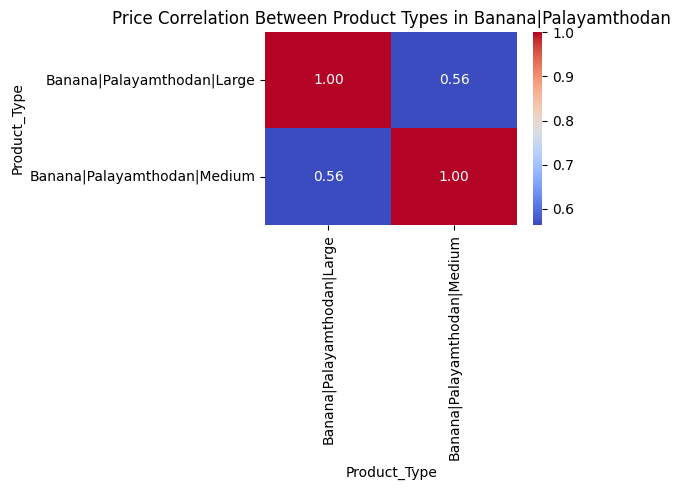

In [17]:
variety = 'Banana|Palayamthodan'  # Select the specific variety type
df_variety = df[df['Variety_Type'] == variety]  # Filter dataset for that variety

# Pivot table: rows = dates, columns = product types, values = modal prices
price_pivot = df_variety.pivot_table(
    index='Arrival_Date',
    columns='Product_Type',
    values='Modal_Price'
)

# Compute pairwise correlations between product types
price_corr = price_pivot.corr()

# Plot heatmap of correlations
plt.figure(figsize=(6, 5))
sns.heatmap(price_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Price Correlation Between Product Types in {variety}')

# Save figure
plt.tight_layout()
plt.savefig("figures/banana_palayamthodan_corr.png", dpi=300)
plt.show()

### Banana – Palayamthodan Variety Correlation Heatmap

The heatmap shows a **moderate positive correlation (0.56)** between  
**Banana | Palayamthodan | Large** and **Banana | Palayamthodan | Medium**.

- Prices move together to some extent, but not as strongly as in the Nendra Bale case.  
- This suggests that while both product types belong to the same variety, their price dynamics are partly shaped by distinct demand-supply conditions, leading to weaker alignment.